<a target="_blank" href="https://colab.research.google.com/github/LSSTC-DSFP/Session-25/tree/main/Day1/SupervisedMLProblems.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# From the lecture...

```python
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Construct features and labels
X = ...
y = ...

# Separate training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Instantiate a model
clf = DecisionTreeClassifier()

# Specify hyperparameter values to test
parameters = {'max_depth': range(1, 20),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': range(1, 4)}

# Run grid search
gridsearch = GridSearchCV(clf, parameters, scoring='accuracy', cv=10)
gridsearch.fit(X_train, y_train)

# Evaluate performance
print(classification_report(y_test, gridsearch.best_estimator_.predict(X_test)))
```

# Problem 0

Load the Wisconsin Breast Cancer dataset into an X, y structure.

Establish training and testing data.

In [1]:
# This one I'll give the solution for since it will be the basis for the other
# problems we'll tackle.

from sklearn.datasets import load_breast_cancer

# let's first use a DataFrame to display the data so we can get a feel for it.
df = load_breast_cancer(as_frame=True)
df.frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
# The DataFrame was fun, but this is the solution to the problem
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Problem 1

Use the workflow from the lecture to train a `DecisionTreeClassifier` and evaluate its performance.

Print out the optimized hyperparameter settings you found.



In [5]:
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier()

parameters = {'max_depth': range(1, 10),
              'criterion' : ['gini', 'entropy'],
              'min_samples_leaf': range(1, 10)
              }

gridsearch = GridSearchCV(clf, parameters, scoring='accuracy', cv=10)

gridsearch.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': range(1, 10), 'min_samples_leaf': range(1, 10)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [6]:
print(classification_report(y_test, gridsearch.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



# Problem 2

Choose another classifier and see if you can get higher accuracy. Use one of the following:

```python
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier  # <-- would recommend
```

For whichever one you choose, determine which hyperparameters you have available to you. To do this, take a quick look at either the scikit-learn docs or perform some introspection of the imported classes.

Heads up, the larger your grid search, the longer your runtime.

In [25]:
from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np
clf = HistGradientBoostingClassifier()

parameters = {'max_depth': np.linspace(1, 10, 5).astype(int),
              'min_samples_leaf': range(1, 4),
              'scoring' : ['accuracy', 'f1']
              }

gridsearch = GridSearchCV(clf, parameters, scoring='accuracy', cv=10, verbose=2)

gridsearch.fit(X_train, y_train)

Fitting 10 folds for each of 30 candidates, totalling 300 fits
[CV] END ..max_depth=1, min_samples_leaf=1, scoring=accuracy; total time=   0.1s
[CV] END ..max_depth=1, min_samples_leaf=1, scoring=accuracy; total time=   0.1s
[CV] END ..max_depth=1, min_samples_leaf=1, scoring=accuracy; total time=   0.1s
[CV] END ..max_depth=1, min_samples_leaf=1, scoring=accuracy; total time=   0.1s
[CV] END ..max_depth=1, min_samples_leaf=1, scoring=accuracy; total time=   0.1s
[CV] END ..max_depth=1, min_samples_leaf=1, scoring=accuracy; total time=   0.1s
[CV] END ..max_depth=1, min_samples_leaf=1, scoring=accuracy; total time=   0.1s
[CV] END ..max_depth=1, min_samples_leaf=1, scoring=accuracy; total time=   0.1s
[CV] END ..max_depth=1, min_samples_leaf=1, scoring=accuracy; total time=   0.1s
[CV] END ..max_depth=1, min_samples_leaf=1, scoring=accuracy; total time=   0.1s
[CV] END ........max_depth=1, min_samples_leaf=1, scoring=f1; total time=   0.1s
[CV] END ........max_depth=1, min_samples_leaf

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ngClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 1, 3, 5, 7, 10]), 'min_samples_leaf': range(1, 4), 'scoring': ['accuracy', 'f1']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

## Problem 2.5

The Random Forest performed the best. Why? It's just a bunch of DecisionTreeClassifiers under the hood, so what makes it out perform?

_Hint: theres a key word in the import statement of the RFC._

Its an ensemble 

# Problem 3

Let's explore the `RandomForestClassifier` a little more.

Use your trained classifer from problem 2, or if you didn't choose the RFC, train one with `criterion='entropy', max_depth=15, n_estimators=20`.

The trained classifier will have an attribute called `feature_importances_`. **Determine what the 5 most important features in the dataset are.**

Classifier introspection is a very useful tool in science / astronomy applications. Reviewers, collaborators, and (hopefully) you as a scientist, will be interested in the key drivers your classifications are based upon.

In [38]:
gridsearch.best_estimator_

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",np.int64(1)
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",1
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'f

In [99]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
clf = RandomForestClassifier(criterion='entropy', max_depth=15, n_estimators=20)

clf.fit(X_train, y_train)

print(clf.feature_importances_)
impt = np.argsort(clf.feature_importances_)[-5:]
top_features = df['feature_names'][impt]
print(top_features)

[0.00245549 0.00892159 0.00673185 0.0664519  0.00526613 0.01900063
 0.03607721 0.0775538  0.00355742 0.00342779 0.00478003 0.00720825
 0.02142392 0.02053711 0.00519049 0.00574574 0.00536517 0.00325184
 0.00756296 0.00461445 0.10964634 0.02619094 0.18518777 0.20409619
 0.02155671 0.02896141 0.02067359 0.06770576 0.01573247 0.00512505]
['worst concave points' 'mean concave points' 'worst radius'
 'worst perimeter' 'worst area']


## Problem 3.5

Make a pairplot of the data for the 5 most important features (or better yet, ask Gemini if working in Colab).

My prompt:
```
using matplotlib, write code for a corner plot to display the distributions of the [<REDACTED: list the features from problem 3 here>] columns of the dataset in this notebook. color the data points by their target_name.
```

Does it make sense that these features were the most important? Do you see separation between the benign and malignant populations?

In [100]:
plot_df = df.frame.loc[:, list(top_features)].copy()
# plot_df["target_name"] = df.target_names[df.target]

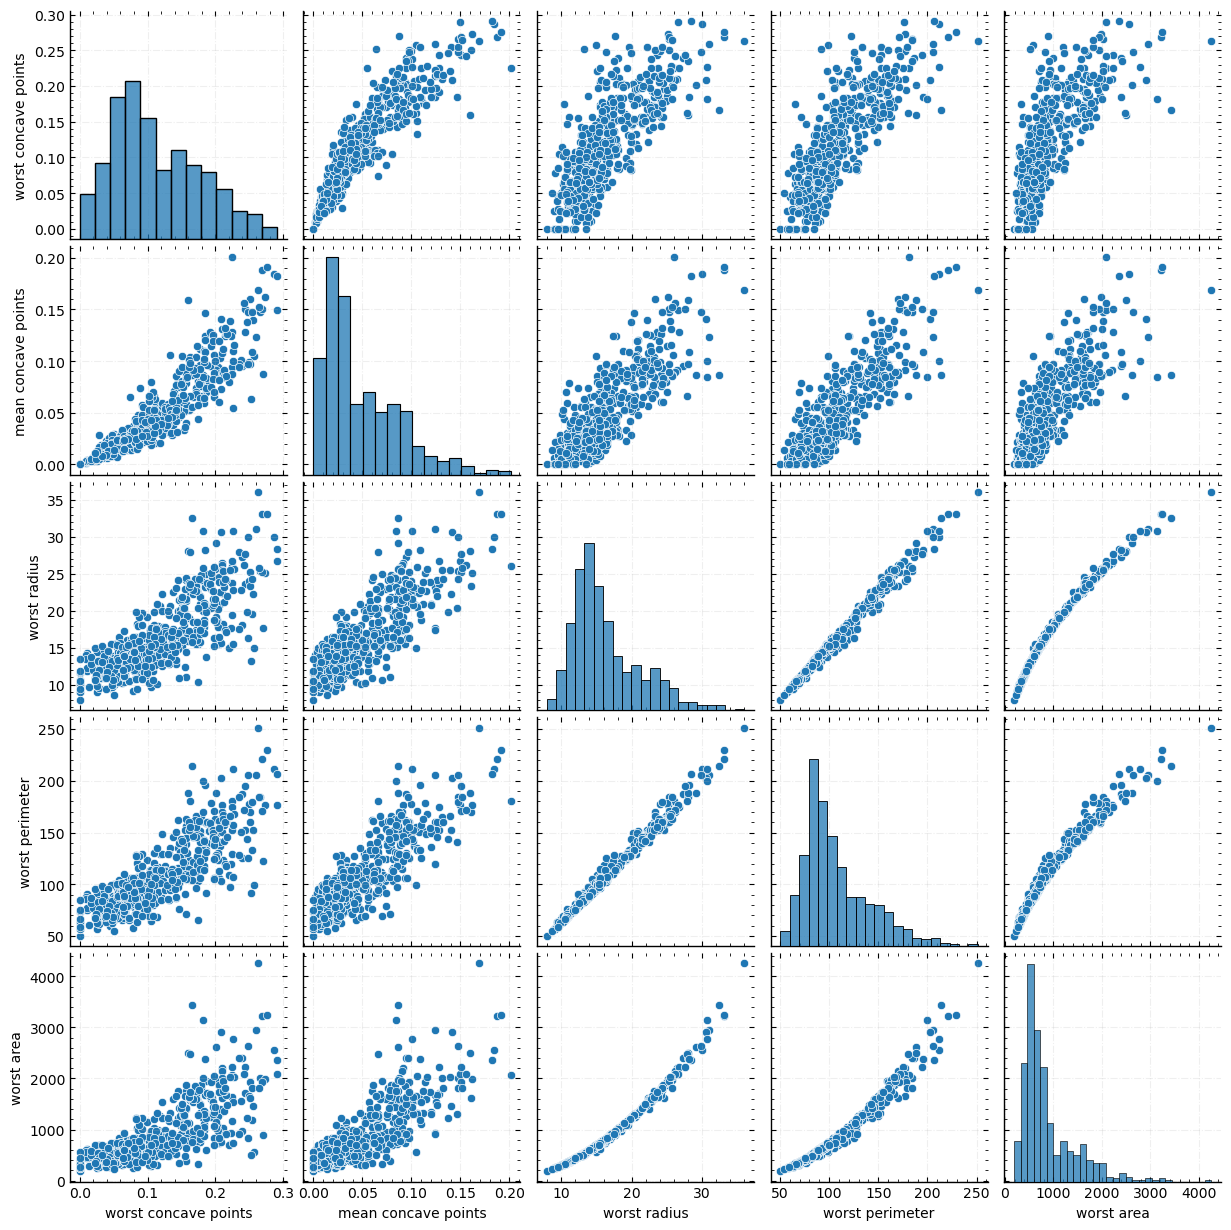

In [101]:
import seaborn as sns

sns.pairplot(plot_df)

# Problem 4

Overall goal: Plot a ROC Curve for your classifier. Add annotations to it that will make the plot publication ready.

### Step 1

Inspect the output of `clf.predict_proba(X)` (assuming your classifier is named `clf`).


In [104]:
clf.predict_proba(X)

array([[1.  , 0.  ],
       [0.95, 0.05],
       [1.  , 0.  ],
       ...,
       [0.95, 0.05],
       [1.  , 0.  ],
       [0.  , 1.  ]], shape=(569, 2))

There are two coloumns in the returned array. The first column is the probability (a statistician might get mad at me calling it a probability, but let's just treat it as such for now) of the example being the first class and the second column is the probablity of the example being the second class.

Now believe it or not, we aren't restricted to classifying examples as benign or malignant using a _probability_ threshold of 0.5. We can choose any threshold on the interval [0, 1] to make our classifications.

### Step 2

Get familiar with the Scikit-Learn `roc_curve` function.

Docs: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html#roc-curve

The `roc_curve` function from Scikit-Learn will return three things: `fpr`, `tpr`, and `thresholds`. You should interpret them as "for a given probability threshold, this is your false positive rate and true positive rate.

### Step 3

Use the `roc_curve` function to get the FPR, TPR, and thresholds arrays. Plot TPR as a function of FPR. Color by threshold if you're feeling fancy.

Text(0, 0.5, 'True Positive Rate')

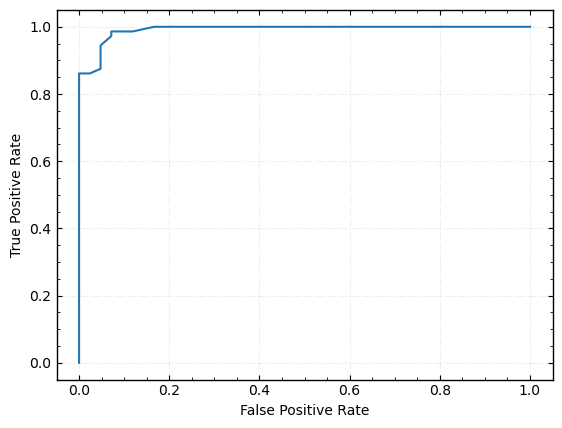

In [126]:
from sklearn import metrics
import matplotlib.pyplot as plt

fpr, tpr, thresholds = metrics.roc_curve(y_test, clf.predict_proba(X_test)[:,1])

plt.plot(fpr, tpr)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

## Problem 4.5

The ROC curve is interpretted as "the closer I can get the elbow of my curve to the point (fpr=0, tpr=1), the better my classification is."

A standard way of measuring that is by computing the area under the curve. The closer to 1.0 the AUC is, the closer you are to perfect classifications.

**Calculate the ROC AUC, and add it to your previous graph in a legend.**

Hint: Of course, Scikit-Learn has a convenient way of doing this: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#roc-auc-score

In [127]:
metrics.roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])

0.9915674603174603

## Problem 4.5.5

Now what threshold should we choose? Let's think about the dataset. This is a toy problem, but one could imagine our classifications being used to make a breast cancer diagnosis for real human patients.

Would you rather prioritize a high TPR and tolerate an FPR? Would you rather prioritize a low FPR and compromise on TPR? Would you like to stay balanced and remain in the middle?

Personally, I would choose to err on the side where I classify a malignant tumor as benign as infrequently as possible, to avoid patients in need missing out on treatment. That is, at the minimum FPR for which TPR = 1.

**Choose an operating threshold, annotate your plot with a star (marker='*') at that threshold, and annotate the point with the FPR and TPR of that threshold.**

Text(0.03, 0.9, '*')

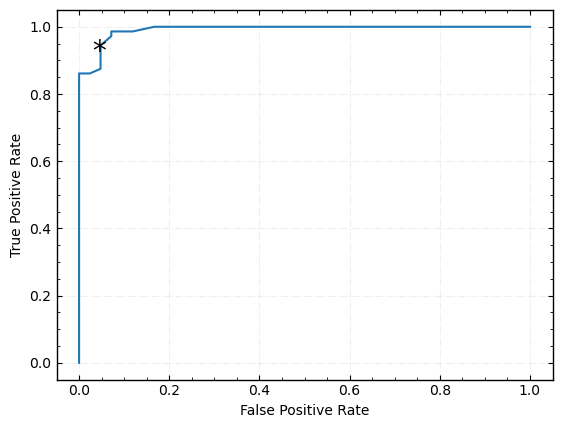

In [145]:
from sklearn import metrics
import matplotlib.pyplot as plt

fpr, tpr, thresholds = metrics.roc_curve(y_test, clf.predict_proba(X_test)[:,1])

fig, ax = plt.subplots()
ax.plot(fpr, tpr)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.text(x=0.03, y=0.9, s = '*', fontsize=20)


# Challenge Problem

In [ ]:
from sklearn.datasets import load_digits
X, y = load_digits(return_X_y=True)

(array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)), array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)))


In [191]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [211]:
from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np
clf = HistGradientBoostingClassifier()

parameters = {
    'learning_rate': [0.1],
    'max_iter': [90, 200],
    'max_leaf_nodes': [10]
}

gridsearch = GridSearchCV(clf, parameters, scoring='accuracy', cv=10, verbose=2)

gridsearch.fit(X_train, y_train)

Fitting 10 folds for each of 2 candidates, totalling 20 fits
[CV] END ..learning_rate=0.1, max_iter=90, max_leaf_nodes=10; total time=   7.1s
[CV] END ..learning_rate=0.1, max_iter=90, max_leaf_nodes=10; total time=   7.0s
[CV] END ..learning_rate=0.1, max_iter=90, max_leaf_nodes=10; total time=   6.8s
[CV] END ..learning_rate=0.1, max_iter=90, max_leaf_nodes=10; total time=   6.8s
[CV] END ..learning_rate=0.1, max_iter=90, max_leaf_nodes=10; total time=   6.7s
[CV] END ..learning_rate=0.1, max_iter=90, max_leaf_nodes=10; total time=   6.7s
[CV] END ..learning_rate=0.1, max_iter=90, max_leaf_nodes=10; total time=   6.7s
[CV] END ..learning_rate=0.1, max_iter=90, max_leaf_nodes=10; total time=   6.8s
[CV] END ..learning_rate=0.1, max_iter=90, max_leaf_nodes=10; total time=   6.7s
[CV] END ..learning_rate=0.1, max_iter=90, max_leaf_nodes=10; total time=   6.7s
[CV] END .learning_rate=0.1, max_iter=200, max_leaf_nodes=10; total time=   8.3s
[CV] END .learning_rate=0.1, max_iter=200, max_l

KeyboardInterrupt: 

In [ ]:
gridsearch.best_estimator_.fit(X_train, y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",90
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",10
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dty

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.89      0.86      0.87        36
           2       1.00      1.00      1.00        35
           3       0.93      1.00      0.96        37
           4       1.00      1.00      1.00        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.90      1.00      0.95        36
           8       0.94      0.83      0.88        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.95       360
weighted avg       0.96      0.96      0.96       360



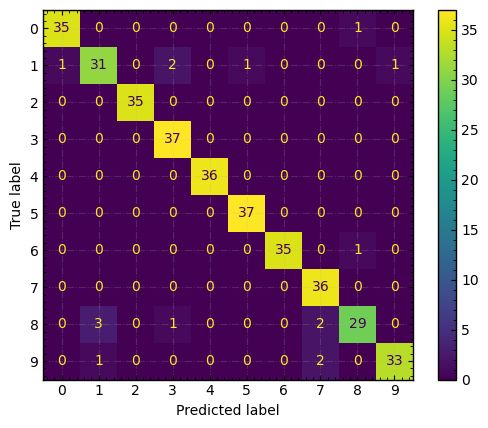

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = gridsearch.predict(X_test)
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
plt.show()